# App-24 — MAPF : auditer les garanties des solveurs

> **Navigation** : [Applications Search](../README.md) · [App-23 PRESENT/SAT](App-23-PRESENT-Differential-Cryptanalysis-SAT.ipynb) · [Search-3 A*](../../Part1-Foundations/Search-03-Informed.ipynb) · [CSP-4 Scheduling](../../Part2-CSP/CSP-4-Scheduling.ipynb)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. valider indépendamment des trajectoires MAPF (mouvements, conflits sommet et arête) ;
2. distinguer **faisabilité**, **optimalité observée** et **garantie algorithmique** ;
3. construire un petit oracle CP-SAT time-expanded pour le makespan ;
4. auditer les hypothèses d'optimalité de CBS, ECBS et OD-A* ;
5. qualifier honnêtement ce qu'un statut `optimal` établit — ou n'établit pas.

**Prérequis** : A*, heuristique admissible, programmation par contraintes, CP-SAT. **Durée estimée** : 60 min.

## Hommage à un travail étudiant

Ce notebook distille le projet G3 *« Coordination de drones par Multi-Agent Path Finding »* de **Matteo Atkinson** et **Paul Witkowski**, EPITA SCIA, Programmation par Contraintes 2026 :

- [répertoire source](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/tree/main/groupe-G3-Coordination_de_drones_par_Multi-Agent_Path_Finding) ;
- [PR #33](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/pull/33) (rendu), [PR #36](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/pull/36) (lancement), [PR #42](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/pull/42) (slides).

Leur appareil combine quatre solveurs — CP-SAT, CBS, ECBS, OD-A* — une API Flask et une visualisation Three.js 3D. Les slides revendiquent des garanties d'optimalité ou de sous-optimalité bornée. CoursIA ne recopie pas ces solveurs : il rejoue trois scénarios, conserve leurs trajectoires sous licence MIT, puis les soumet à un **validateur** et à un **oracle** indépendants. La question n'est donc pas « quel solveur est le plus rapide ? », mais : **quelle preuve autorise chaque étiquette ?**

> **Provenance.** Les données dérivées, le SHA source, le protocole de collecte et les limites sont consignés dans [`data/app24-mapf-audit/SOURCE.md`](data/app24-mapf-audit/SOURCE.md).

## 1. Charger le snapshot frais

Le notebook est autonome : il lit un petit snapshot JSON issu du rerun du code étudiant, sans importer le dépôt PrCon ni ses solveurs.

In [1]:
from pathlib import Path
import json
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
from ortools.sat.python import cp_model


def locate_data():
    for base in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        candidate = base / "data" / "app24-mapf-audit" / "fresh_runs.json"
        if candidate.exists():
            return candidate
    return Path.cwd() / "data" / "app24-mapf-audit" / "fresh_runs.json"


DATA_PATH = locate_data()
data = json.loads(DATA_PATH.read_text(encoding="utf-8"))
print(f"Snapshot chargé : {len(data['scenarios'])} scénarios, commit source {data['source_commit'][:10]}")
print("Auteurs crédités :", ", ".join(data["students"]))

Snapshot chargé : 3 scénarios, commit source b5f3f0351d
Auteurs crédités : Matteo Atkinson, Paul Witkowski


**Interprétation.** Le snapshot nomme ses auteurs et son commit source. Cette traçabilité permet de reproduire le même appareil, mais elle ne transforme pas les sorties sérialisées en vérité : toutes les propriétés importantes seront recalculées ci-dessous.

## 2. Formaliser MAPF : espace, conflits et objectifs

Un agent occupe une position discrète par pas de temps. Il peut attendre ou rejoindre une case voisine. Deux conflits sont interdits :

- **sommet** : deux agents sur la même position au même instant ;
- **arête (swap)** : deux agents échangent leurs positions pendant le même pas.

Après la fin d'une trajectoire, l'agent reste à son but. Le **makespan** est le dernier temps d'arrivée ; le **flowtime** est la somme des temps d'arrivée.

In [2]:
def scenario_positions(scenario):
    rows, cols = scenario["grid"]["rows"], scenario["grid"]["cols"]
    alts = scenario["grid"].get("alts", 1)
    obstacles = set()
    for building in scenario.get("buildings", []):
        if alts == 1:
            obstacles.add((building["row"], building["col"]))
        else:
            obstacles.update(
                (building["row"], building["col"], altitude)
                for altitude in range(building["height"])
            )
    if alts == 1:
        return [(r, c) for r in range(rows) for c in range(cols) if (r, c) not in obstacles]
    return [
        (r, c, a)
        for r in range(rows) for c in range(cols) for a in range(alts)
        if (r, c, a) not in obstacles
    ]


def neighbors(position, valid_positions):
    valid = set(valid_positions)
    candidates = [position]
    for axis in range(len(position)):
        for delta in (-1, 1):
            moved = list(position)
            moved[axis] += delta
            candidates.append(tuple(moved))
    return [candidate for candidate in candidates if candidate in valid]


def stable_arrival(path, goal):
    return next(
        t for t in range(len(path))
        if all(tuple(position) == goal for position in path[t:])
    )


def objectives(drones, paths):
    arrivals = []
    for drone in drones:
        path = paths[str(drone["id"])]
        goal = tuple(drone["goal"])
        arrivals.append(stable_arrival(path, goal))
    return max(arrivals), sum(arrivals)


for scenario in data["scenarios"]:
    print(f"{scenario['name']:12s} : {len(scenario_positions(scenario)):2d} positions, {len(scenario['drones'])} agents")

micro_flat   : 16 positions, 3 agents
micro_3d     : 44 positions, 4 agents
medium_flat  : 48 positions, 5 agents


**Interprétation.** Les trois instances couvrent une grille 2D minimale, une grille 3D avec bâtiments et une grille 2D moyenne. Les objectifs sont recalculés depuis les trajectoires plutôt que crus depuis les champs `makespan` et `flowtime`.

## 3. Un validateur indépendant répond seulement « faisable ? »

Le validateur ci-dessous ne connaît ni CP-SAT, ni CBS, ni OD-A*. Il vérifie les endpoints, les mouvements, les conflits et la persistance au but.

In [3]:
def validate_paths(scenario, paths):
    issues = []
    drones = scenario["drones"]
    valid = set(scenario_positions(scenario))
    expected_ids = {str(drone["id"]) for drone in drones}
    if set(paths) != expected_ids:
        return ["ensemble d'agents incorrect"]

    for drone in drones:
        agent = str(drone["id"])
        path = [tuple(position) for position in paths[agent]]
        if not path or path[0] != tuple(drone["start"]) or path[-1] != tuple(drone["goal"]):
            issues.append(f"agent {agent}: endpoints invalides")
        for t, position in enumerate(path):
            if position not in valid:
                issues.append(f"agent {agent}: position invalide à t={t}")
            if t and position not in neighbors(path[t - 1], valid):
                issues.append(f"agent {agent}: mouvement invalide à t={t}")

    horizon = max(len(path) for path in paths.values())
    for t in range(horizon):
        now = {
            agent: tuple(path[min(t, len(path) - 1)])
            for agent, path in paths.items()
        }
        if len(set(now.values())) != len(now):
            issues.append(f"conflit sommet à t={t}")
        if t + 1 < horizon:
            nxt = {
                agent: tuple(path[min(t + 1, len(path) - 1)])
                for agent, path in paths.items()
            }
            for first, second in combinations(now, 2):
                if now[first] == nxt[second] and now[second] == nxt[first]:
                    issues.append(f"conflit arête {first}/{second} à t={t}")
    return issues


validation_rows = []
for scenario in data["scenarios"]:
    for run in scenario["runs"]:
        computed_makespan, computed_flowtime = objectives(scenario["drones"], run["paths"])
        issues = validate_paths(scenario, run["paths"])
        validation_rows.append({
            "scénario": scenario["name"],
            "solveur": run["solver"],
            "statut déclaré": run["declared_status"],
            "makespan recalculé": computed_makespan,
            "flowtime recalculé": computed_flowtime,
            "validation": "OK" if not issues else "; ".join(issues),
        })
validation = pd.DataFrame(validation_rows)
print(validation.to_string(index=False))
assert validation["validation"].eq("OK").all()

   scénario solveur statut déclaré  makespan recalculé  flowtime recalculé validation
 micro_flat  CP-SAT        optimal                   6                  18         OK
 micro_flat     CBS        optimal                   6                  18         OK
 micro_flat   OD-A*        optimal                   8                  20         OK
   micro_3d  CP-SAT        optimal                   8                  30         OK
   micro_3d     CBS        optimal                   8                  30         OK
   micro_3d   OD-A*        optimal                   8                  30         OK
medium_flat  CP-SAT        optimal                  12                  54         OK
medium_flat     CBS        optimal                  12                  49         OK
medium_flat   OD-A*        optimal                  16                  60         OK


**Interprétation.** Toutes les trajectoires du snapshot passent les contrôles indépendants. Les temps d'arrivée sont comptés à partir de l'instant où chaque agent reste définitivement au but : une visite suivie d'un départ n'est pas une arrivée. Ce résultat établit la **faisabilité** sur ces trois instances, sans prouver l'optimalité du makespan ou du flowtime.

### Exercice 1 — Détecter un swap

Complétez un contrôle isolé qui reçoit deux chemins et retourne les instants où les agents échangent leurs positions.

**Indice :** comparer `(a[t], a[t+1])` à `(b[t+1], b[t])`.

In [4]:
def swap_times(path_a, path_b):
    # TODO étudiant : parcourir l'horizon commun et retourner les instants de swap.
    result = None
    return result


print("Exercice a completer")

Exercice a completer


**Point de contrôle.** Un conflit arête est temporel : deux agents peuvent visiter les mêmes cases à des instants différents sans collision.

## 4. Makespan et flowtime ne racontent pas la même histoire

Deux solutions peuvent s'inverser selon l'objectif. L'exemple guide suivant utilise directement des temps d'arrivée.

In [5]:
arrivals_a = [2, 2, 8]
arrivals_b = [5, 5, 5]
metrics = pd.DataFrame([
    {"solution": "A", "makespan": max(arrivals_a), "flowtime": sum(arrivals_a)},
    {"solution": "B", "makespan": max(arrivals_b), "flowtime": sum(arrivals_b)},
])
print(metrics.to_string(index=False))
print("Préférence makespan :", metrics.loc[metrics["makespan"].idxmin(), "solution"])
print("Préférence flowtime :", metrics.loc[metrics["flowtime"].idxmin(), "solution"])

solution  makespan  flowtime
       A         8        12
       B         5        15
Préférence makespan : B
Préférence flowtime : A


**Interprétation.** B minimise le makespan, tandis que A minimise le flowtime. Une étiquette `optimal` sans objectif nommé est donc incomplète.

### Exercice 2 — Construire une inversion d'objectifs

Proposez deux vecteurs de temps d'arrivée pour quatre agents tels que le premier ait le meilleur makespan et le second le meilleur flowtime.

In [6]:
# TODO étudiant : remplacer ces valeurs par deux vecteurs qui inversent les préférences.
arrivals_first = None
arrivals_second = None
print("Exercice a completer")

Exercice a completer


**Point de contrôle.** Avant de comparer des solveurs, écrire noir sur blanc l'objectif qu'ils optimisent évite de transformer une différence de métrique en défaut algorithmique.

## 5. Un oracle CP-SAT indépendant pour le makespan

Pour chaque horizon `H`, l'oracle crée les booléens `x[a,p,t]`, impose une position par agent et par temps, les mouvements légaux, la persistance au but, puis interdit conflits sommet et swaps. Le premier horizon faisable est le makespan optimal **du modèle fini**.

In [7]:
def manhattan(first, second):
    return sum(abs(a - b) for a, b in zip(first, second))


def solve_at_horizon(scenario, horizon, time_limit=20.0):
    positions = scenario_positions(scenario)
    index = {position: i for i, position in enumerate(positions)}
    nbrs = {p: [index[q] for q in neighbors(position, positions)] for p, position in enumerate(positions)}
    drones = scenario["drones"]
    model = cp_model.CpModel()
    x = {
        (a, p, t): model.NewBoolVar(f"x_{a}_{p}_{t}")
        for a in range(len(drones)) for p in range(len(positions)) for t in range(horizon + 1)
    }

    for a, drone in enumerate(drones):
        for t in range(horizon + 1):
            model.AddExactlyOne(x[a, p, t] for p in range(len(positions)))
        model.Add(x[a, index[tuple(drone["start"])], 0] == 1)
        goal_index = index[tuple(drone["goal"])]
        model.Add(x[a, goal_index, horizon] == 1)
        for t in range(horizon):
            model.Add(x[a, goal_index, t] <= x[a, goal_index, t + 1])
            for p in range(len(positions)):
                model.Add(x[a, p, t] <= sum(x[a, q, t + 1] for q in nbrs[p]))

    for t in range(horizon + 1):
        for p in range(len(positions)):
            model.AddAtMostOne(x[a, p, t] for a in range(len(drones)))

    directed_edges = {
        (p, q)
        for p, qs in nbrs.items() for q in qs if p != q
    }
    for t in range(horizon):
        for p, q in directed_edges:
            for first, second in combinations(range(len(drones)), 2):
                model.Add(
                    x[first, p, t] + x[first, q, t + 1]
                    + x[second, q, t] + x[second, p, t + 1] <= 3
                )

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 4
    status = solver.Solve(model)
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None, solver.StatusName(status)
    paths = {}
    for a, drone in enumerate(drones):
        paths[str(drone["id"])] = [
            list(positions[next(p for p in range(len(positions)) if solver.Value(x[a, p, t]))])
            for t in range(horizon + 1)
        ]
    return paths, solver.StatusName(status)


def makespan_oracle(scenario):
    lower = max(
        manhattan(tuple(drone["start"]), tuple(drone["goal"]))
        for drone in scenario["drones"]
    )
    for horizon in range(lower, lower + 21):
        paths, status = solve_at_horizon(scenario, horizon)
        if paths is not None:
            return horizon, paths, status, lower
    raise RuntimeError("Aucune solution trouvée dans la fenêtre d'horizons auditée")


print("Oracle défini : recherche croissante du premier horizon faisable")

Oracle défini : recherche croissante du premier horizon faisable


**Interprétation.** L'oracle ne réutilise ni l'horizon ni les contraintes du solveur étudiant. La recherche croissante rend la borne inférieure et le premier horizon faisable visibles ; le statut CP-SAT reste attaché à chaque modèle fini.

In [8]:
oracle_rows = []
oracle_paths = {}
for scenario in data["scenarios"]:
    optimum, paths, status, lower = makespan_oracle(scenario)
    issues = validate_paths(scenario, paths)
    assert not issues
    oracle_paths[scenario["name"]] = paths
    oracle_rows.append({
        "scénario": scenario["name"],
        "borne inférieure": lower,
        "makespan oracle": optimum,
        "statut CP-SAT": status,
        "validation": "OK",
    })
oracle = pd.DataFrame(oracle_rows)
print(oracle.to_string(index=False))

   scénario  borne inférieure  makespan oracle statut CP-SAT validation
 micro_flat                 6                6       OPTIMAL         OK
   micro_3d                 8                8       OPTIMAL         OK
medium_flat                12               12       OPTIMAL         OK


**Interprétation.** Sur chaque petite instance, la borne de distance et le premier horizon faisable coïncident ou sont séparés par la coordination requise. Le résultat établit un makespan minimal pour ce modèle explicite et cette recherche d'horizons — pas une garantie universelle sur le code étudiant.

## 6. Réfuter un statut `optimal` par un contre-exemple

Comparons maintenant les makespans déclarés à l'oracle indépendant.

   scénario solveur statut déclaré  makespan recalculé  makespan oracle  écart makespan
 micro_flat  CP-SAT        optimal                   6                6               0
 micro_flat     CBS        optimal                   6                6               0
 micro_flat   OD-A*        optimal                   8                6               2
   micro_3d  CP-SAT        optimal                   8                8               0
   micro_3d     CBS        optimal                   8                8               0
   micro_3d   OD-A*        optimal                   8                8               0
medium_flat  CP-SAT        optimal                  12               12               0
medium_flat     CBS        optimal                  12               12               0
medium_flat   OD-A*        optimal                  16               12               4


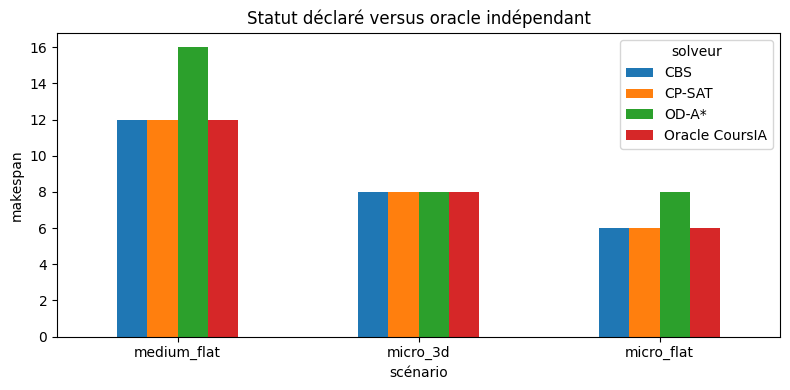

In [9]:
comparison = validation.merge(oracle[["scénario", "makespan oracle"]], on="scénario")
comparison["écart makespan"] = comparison["makespan recalculé"] - comparison["makespan oracle"]
print(comparison[["scénario", "solveur", "statut déclaré", "makespan recalculé", "makespan oracle", "écart makespan"]].to_string(index=False))

pivot = comparison.pivot(index="scénario", columns="solveur", values="makespan recalculé")
pivot["Oracle CoursIA"] = oracle.set_index("scénario")["makespan oracle"]
pivot.plot(kind="bar", figsize=(8, 4), ylabel="makespan", rot=0,
           title="Statut déclaré versus oracle indépendant")
plt.tight_layout()
plt.show()

od_refutations = comparison.query("solveur == 'OD-A*' and `écart makespan` > 0")
assert len(od_refutations) == 2

**Interprétation.** OD-A* retourne `optimal` alors que son makespan dépasse l'oracle sur **deux scénarios**. Les trajectoires restent valides : le contre-exemple réfute précisément le **statut d'optimalité**, pas la faisabilité du solveur. Sur le scénario 3D, le makespan est égal mais le flowtime diffère ; cet écart ne réfute pas une prétention limitée au makespan.

## 7. Pourquoi l'heuristique OD-A* ne porte pas la garantie annoncée

Dans l'implémentation étudiante, `g` augmente d'une unité par timestep joint, tandis que `h` additionne les distances restantes de tous les agents. Pour minimiser le makespan, le coût restant est gouverné par un **maximum**, pas par une somme.

In [10]:
micro = data["scenarios"][0]
remaining_distances = [
    manhattan(tuple(drone["start"]), tuple(drone["goal"]))
    for drone in micro["drones"]
]
h_sum = sum(remaining_distances)
true_parallel_lower_bound = max(remaining_distances)
print("Distances individuelles :", remaining_distances)
print("Heuristique somme utilisée :", h_sum)
print("Borne makespan par mouvements parallèles :", true_parallel_lower_bound)
print("Admissible pour le makespan :", h_sum <= true_parallel_lower_bound)
assert h_sum > true_parallel_lower_bound

Distances individuelles : [6, 6, 6]
Heuristique somme utilisée : 18
Borne makespan par mouvements parallèles : 6
Admissible pour le makespan : False


**Interprétation.** Dès l'état initial, la somme surestime le nombre minimal de timesteps parallèles. Elle peut être pertinente pour une somme de coûts, mais elle n'est pas admissible pour le makespan avec ce `g`. Le théorème d'optimalité de A* ne s'applique donc pas à ce couple coût/heuristique.

## 8. CBS : arriver au but ne suffit pas face à une contrainte future

Le snapshot contient un cas 1×3 : l'agent atteint son but à `t=2`, mais ce même but est interdit à `t=4`. Avec persistance au but, retourner immédiatement à `pos == goal` viole la contrainte future.

In [11]:
case = data["future_goal_case"]
path = [tuple(position) for position in case["student_low_level_path"]]
goal = tuple(case["goal"])
forbidden_time = case["forbidden"]["time"]


def safe_goal_termination(path, goal_position, constraints):
    arrival = len(path) - 1
    return path[-1] == goal_position and all(
        position != goal_position or time <= arrival
        for position, time in constraints
    )


constraints = {(tuple(case["forbidden"]["position"]), forbidden_time)}
print("Chemin low-level retourné :", path)
print("Arrêt naïf `pos == goal` :", path[-1] == goal)
print("Arrêt sûr avec contraintes futures :", safe_goal_termination(path, goal, constraints))
print("Contrainte future respectée selon le rerun :", case["constraint_respected"])
assert path[-1] == goal and not safe_goal_termination(path, goal, constraints)

Chemin low-level retourné : [(0, 0), (0, 1), (0, 2)]
Arrêt naïf `pos == goal` : True
Arrêt sûr avec contraintes futures : False
Contrainte future respectée selon le rerun : False


**Interprétation.** Le micro-cas reproduit un défaut du low-level A* : la solution est rendue avant d'examiner une interdiction future au but. Comme CBS et ECBS réutilisent ce low-level et un horizon empirique, les garanties de leurs versions canoniques ne sont pas automatiquement transférées à cette implémentation.

### Exercice 3 — Restaurer le contrat de garantie

Complétez un prédicat d'arrêt qui n'accepte le but que si aucune contrainte future ne l'interdit. Puis indiquez quelles autres hypothèses (horizon, coût, heuristique) devraient être auditées pour CBS ou ECBS.

**Indice :** chercher le plus grand temps interdit au but.

In [12]:
def goal_is_safe(goal_position, arrival_time, constraints):
    # TODO étudiant : refuser si le but est interdit après arrival_time.
    result = None
    return result


print("Exercice a completer")

Exercice a completer


**Point de contrôle.** Réparer le prédicat d'arrêt est nécessaire mais ne prouve pas à lui seul toute l'implémentation : l'horizon et l'ordre de coût restent à justifier.

## 9. ECBS : une formule FOCAL n'est pas une preuve complète

ECBS sélectionne classiquement dans un ensemble `FOCAL` borné par `w × f_min`. Cette règle peut soutenir une garantie w-sous-optimale si les bornes, les coûts et le low-level satisfont les hypothèses du théorème. Ici, le low-level présente le défaut reproduit ci-dessus et l'horizon est empirique. Les sorties peuvent être bonnes ; la borne `≤ w × optimum` de **cette implémentation** reste **non établie** par les trois scénarios.

## 10. Matrice des niveaux de preuve

In [13]:
evidence = pd.DataFrame([
    ["CP-SAT étudiant", "trajectoires valides sur 3 scénarios", "optimum CoursIA sous modèle fini", "suffisance générale de l'horizon étudiant"],
    ["CBS étudiant", "valide et égal à l'oracle sur 3 scénarios", "égalité sur ces instances", "garantie générale (but futur + horizon)"],
    ["ECBS étudiant", "architecture et résultats rapportés", "aucune borne w certifiée ici", "garantie w de cette implémentation"],
    ["OD-A* étudiant", "trajectoires valides", "sous-optimalité sur 2 scénarios", "statut `optimal`"],
], columns=["Solveur", "Ce que montre le rerun", "Ce que l'oracle établit", "Ce qui reste non prouvé"])
print(evidence.to_string(index=False))

        Solveur                    Ce que montre le rerun          Ce que l'oracle établit                   Ce qui reste non prouvé
CP-SAT étudiant      trajectoires valides sur 3 scénarios optimum CoursIA sous modèle fini suffisance générale de l'horizon étudiant
   CBS étudiant valide et égal à l'oracle sur 3 scénarios        égalité sur ces instances   garantie générale (but futur + horizon)
  ECBS étudiant       architecture et résultats rapportés     aucune borne w certifiée ici        garantie w de cette implémentation
 OD-A* étudiant                      trajectoires valides  sous-optimalité sur 2 scénarios                          statut `optimal`


**Interprétation.** La matrice empêche le glissement le plus fréquent : passer de « le résultat est bon ici » à « l'algorithme est garanti ». Un validateur, un oracle borné et un théorème répondent à trois questions différentes.

## 11. Limites honnêtes

1. **Trois scénarios seulement.** Ils suffisent à produire des contre-exemples, pas à caractériser la scalabilité.
2. **Snapshot dérivé d'un commit.** Une modification future du projet étudiant exige une nouvelle collecte et une nouvelle attribution.
3. **Oracle borné.** La recherche croissante établit le premier horizon faisable des petits modèles construits ici ; elle ne certifie pas toutes les variantes MAPF.
4. **Makespan privilégié.** Le notebook calcule aussi le flowtime mais l'oracle minimise le makespan. Une optimalité flowtime demanderait un autre objectif.
5. **Pas de benchmark runtime.** Les temps absolus dépendent de la machine et ne sont pas utilisés pour classer les solveurs.
6. **Pas de certification de l'application complète.** L'API Flask, la visualisation Three.js, les zones dynamiques et les grands scénarios ne sont pas audités ici.
7. **Pas de preuve formelle.** CP-SAT fournit un statut sur un modèle exécutable ; aucun certificat indépendant ni preuve Lean de l'encodage n'est produit.

## 12. Conclusion

Le geste de Matteo Atkinson et Paul Witkowski est conservé et élargi : leur comparaison de solveurs devient un laboratoire d'**audit des garanties**. Les trajectoires fraîches sont faisables ; l'oracle confirme plusieurs optima observés, réfute deux statuts OD-A*, et le micro-cas CBS révèle une hypothèse d'arrêt violée.

Quatre règles se généralisent au-delà de MAPF :

1. **valide** ne signifie pas **optimal** ;
2. égaler un oracle sur quelques instances ne donne pas une garantie générale ;
3. un statut retourné n'est pas un certificat ;
4. la preuve d'un algorithme canonique ne couvre une implémentation que si ses hypothèses sont préservées.

## Sources

- Stern, R., et al. (2019), *Multi-Agent Pathfinding: Definitions, Variants, and Benchmarks*, SoCS.
- Sharon, G., et al. (2015), *Conflict-Based Search for Optimal Multi-Agent Path Finding*, Artificial Intelligence 219.
- Standley, T. (2010), *Finding Optimal Solutions to Cooperative Pathfinding Problems*, AAAI.
- Barer, M., et al. (2014), *Suboptimal Variants of the Conflict-Based Search Algorithm for the Multi-Agent Pathfinding Problem*, SoCS.
- Projet G3 et historique PrCon : PRs #33, #36 et #42, liens en introduction.